# ACE / NME / ALA analysis

In [1]:
def add_panel_label(ax, label, dx=0.0, dy=0.02):
    """Aggiunge una lettera di pannello (A, B, ...) in alto a sinistra del pannello."""
    ax.text(0.0 + dx, 1.0 + dy, label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14, weight="bold",
            color="#222222")


In [2]:
import mdtraj as md
import numpy as np
from collections import defaultdict

# === Paths (edit if necessary) ===
conf = "../../../dataset_aladip/alaninedipeptide_H.pdb"
traj = "../../../dataset_aladip//alaninedipeptide_reduced.xtc"

lows = '../../lows.txt'
torsions = '../../../dataset_aladip/torsions'

proj = np.loadtxt(lows)
torsions_data = np.loadtxt(torsions)

# === Load trajectory ===
t = md.load_xtc(traj, top=conf)
top = t.topology
time_ps = t.time if t.time is not None else np.arange(t.n_frames, dtype=float)

# ========== 1) φ and ψ of the central ALA ==========
phi_idx, phi_all = md.compute_phi(t)   # radians
psi_idx, psi_all = md.compute_psi(t)   # radians

def res_from_quad(q, topology):
    # for MDTraj, the 2nd atom in the quadruplet (index 1) is the CA of the residue of interest
    return topology.atom(q[1]).residue

phi_res = [res_from_quad(q, top) for q in phi_idx]
psi_res = [res_from_quad(q, top) for q in psi_idx]

ala_candidates = [r for r in set(phi_res).intersection(psi_res) if r.name.upper() == "ALA"]
if not ala_candidates:
    ala_candidates = list(set(phi_res).intersection(psi_res))
ala = sorted(ala_candidates, key=lambda r: r.index)[0]

def pick_angle_for_res(idxs, vals, res, topology):
    for i, q in enumerate(idxs):
        if topology.atom(q[1]).residue.index == res.index:
            return vals[:, i]
    return None

phi = pick_angle_for_res(phi_idx, phi_all, ala, top)
psi = pick_angle_for_res(psi_idx, psi_all, ala, top)
phi_deg = np.degrees(phi) if phi is not None else None
psi_deg = np.degrees(psi) if psi is not None else None

# ========== 2) Build bond map (compatible with all MDTraj versions) ==========
bond_map = {}
for b in top.bonds:
    a1, a2 = b.atom1, b.atom2
    bond_map.setdefault(a1.index, []).append(a2)
    bond_map.setdefault(a2.index, []).append(a1)

def neighbors(atom):
    """Covalent neighbors of an atom using the bond map."""
    return bond_map.get(atom.index, [])

# Utility
def is_H(a): return a.element.symbol == "H"
def is_C(a): return a.element.symbol == "C"

# ========== 3) Choose the fourth atom (Y) for H–Cmet–X–Y dihedrals ==========
def choose_Y(res, Cmet, X):
    """
    Choose Y among the (heavy) neighbors of X, avoiding Cmet.
    Rules:
      - ACE: X = carbonyl C → prefer O (carbonyl oxygen)
      - NME: X = N → prefer carbonyl C (bonded to both N and O)
      - ALA side chain (Cmet=CB): X=CA → prefer N (backbone), then C
      - Generic fallback: O if present, then N/C/CA/OXT, otherwise any heavy atom
    """
    nbrs_X = neighbors(X)
    heavy = [a for a in nbrs_X if a.index != Cmet.index and a.element.symbol != "H"]
    if not heavy:
        return None

    rname = res.name.upper()
    # ACE: CH3–C(=O)–...
    if rname == "ACE" and X.element.symbol == "C":
        # prefer a carbonyl oxygen
        for a in heavy:
            if a.element.symbol == "O":
                return a
    # NME: CH3–N–C(=O)...
    if rname == "NME" and X.element.symbol == "N":
        # prefer a carbonyl carbon (usually "C") bonded to an O
        for a in heavy:
            if a.element.symbol == "C":
                if any(nbr.element.symbol == "O" for nbr in neighbors(a)):
                    return a
    # ALA side chain: CH3(CB)–CA–N/C
    if rname == "ALA" and Cmet.name.upper() == "CB" and X.name.upper() == "CA":
        # prefer N, then C
        for pref in ("N", "C"):
            for a in heavy:
                if a.name.upper() == pref:
                    return a

    # generic fallback: O, then backbone atoms, then any heavy atom
    for a in heavy:
        if a.element.symbol == "O":
            return a
    for aname in ("N", "C", "CA", "OXT"):
        for a in heavy:
            if a.name.upper() == aname:
                return a
    return heavy[0]

# ========== 4) Identify all methyl groups and compute angles ==========
methyls = []  # list of dicts with info and angles in degrees

for res in top.residues:
    for atom in res.atoms:
        if not is_C(atom):
            continue
        nbrs = neighbors(atom)
        Hs = [a for a in nbrs if is_H(a)]
        heavies = [a for a in nbrs if a.element.symbol != "H"]
        # Methyl group: C with exactly 3 H and one heavy neighbor
        if len(Hs) == 3 and len(heavies) == 1:
            Cmet = atom
            X = heavies[0]
            Y = choose_Y(res, Cmet, X)
            if Y is None:
                continue

            quartets = np.array([[h.index, Cmet.index, X.index, Y.index] for h in Hs], dtype=int)
            angles = md.compute_dihedrals(t, quartets)     # radians, shape (n_frames, 3)
            angles_deg = np.degrees(angles)                # degrees

            methyls.append({
                "residue": res,
                "Cmet": Cmet,
                "Hs": Hs,
                "X": X,
                "Y": Y,
                "quartets": quartets,
                "angles_deg": angles_deg,
            })

# ========== 5) Group by category: ACE, NME, ALA side chain ==========
by_cat = defaultdict(list)
for m in methyls:
    res = m["residue"]
    rname = res.name.upper()
    if rname == "ACE":
        by_cat["ACE"].append(m["angles_deg"])
    elif rname == "NME":
        by_cat["NME"].append(m["angles_deg"])
    elif rname == "ALA" and m["Cmet"].name.upper() in ("CB", "CH3", "CT3"):
        by_cat["ALA_SC"].append(m["angles_deg"])

def stack_or_none(list_of_arrays):
    if not list_of_arrays:
        return None
    # each element: (n_frames, 3) → concatenate along columns
    return np.concatenate(list_of_arrays, axis=1)

ace_methyl_deg = stack_or_none(by_cat["ACE"])         # (n_frames, 3*k_ace) or None
nme_methyl_deg = stack_or_none(by_cat["NME"])         # (n_frames, 3*k_nme) or None
ala_sc_methyl_deg = stack_or_none(by_cat["ALA_SC"])   # (n_frames, 3*k_ala) or None

# ========== 6) (Optional) Small summary on screen ==========
print(f"[Central ALA] index={ala.index}, name={ala.name}")
print("phi_deg shape:", None if phi_deg is None else phi_deg.shape)
print("psi_deg shape:", None if psi_deg is None else psi_deg.shape)

def tag(m):
    r = m["residue"]
    return f"{r.name}-{r.index}"

for m in methyls:
    print(f"Methyl {tag(m)} | Cmet={m['Cmet'].name}  X={m['X'].name}  Y={m['Y'].name}  -> angles {m['angles_deg'].shape}")

print("ACE methyl shape:", None if ace_methyl_deg is None else ace_methyl_deg.shape)
print("NME methyl shape:", None if nme_methyl_deg is None else nme_methyl_deg.shape)
print("ALA side-chain methyl shape:", None if ala_sc_methyl_deg is None else ala_sc_methyl_deg.shape)



[Central ALA] index=1, name=ALA
phi_deg shape: (100001,)
psi_deg shape: (100001,)
Methyl ACE-0 | Cmet=CH3  X=C  Y=O  -> angles (100001, 3)
Methyl ALA-1 | Cmet=CB  X=CA  Y=N  -> angles (100001, 3)
Methyl NME-2 | Cmet=C  X=N  Y=C  -> angles (100001, 3)
ACE methyl shape: (100001, 3)
NME methyl shape: (100001, 3)
ALA side-chain methyl shape: (100001, 3)


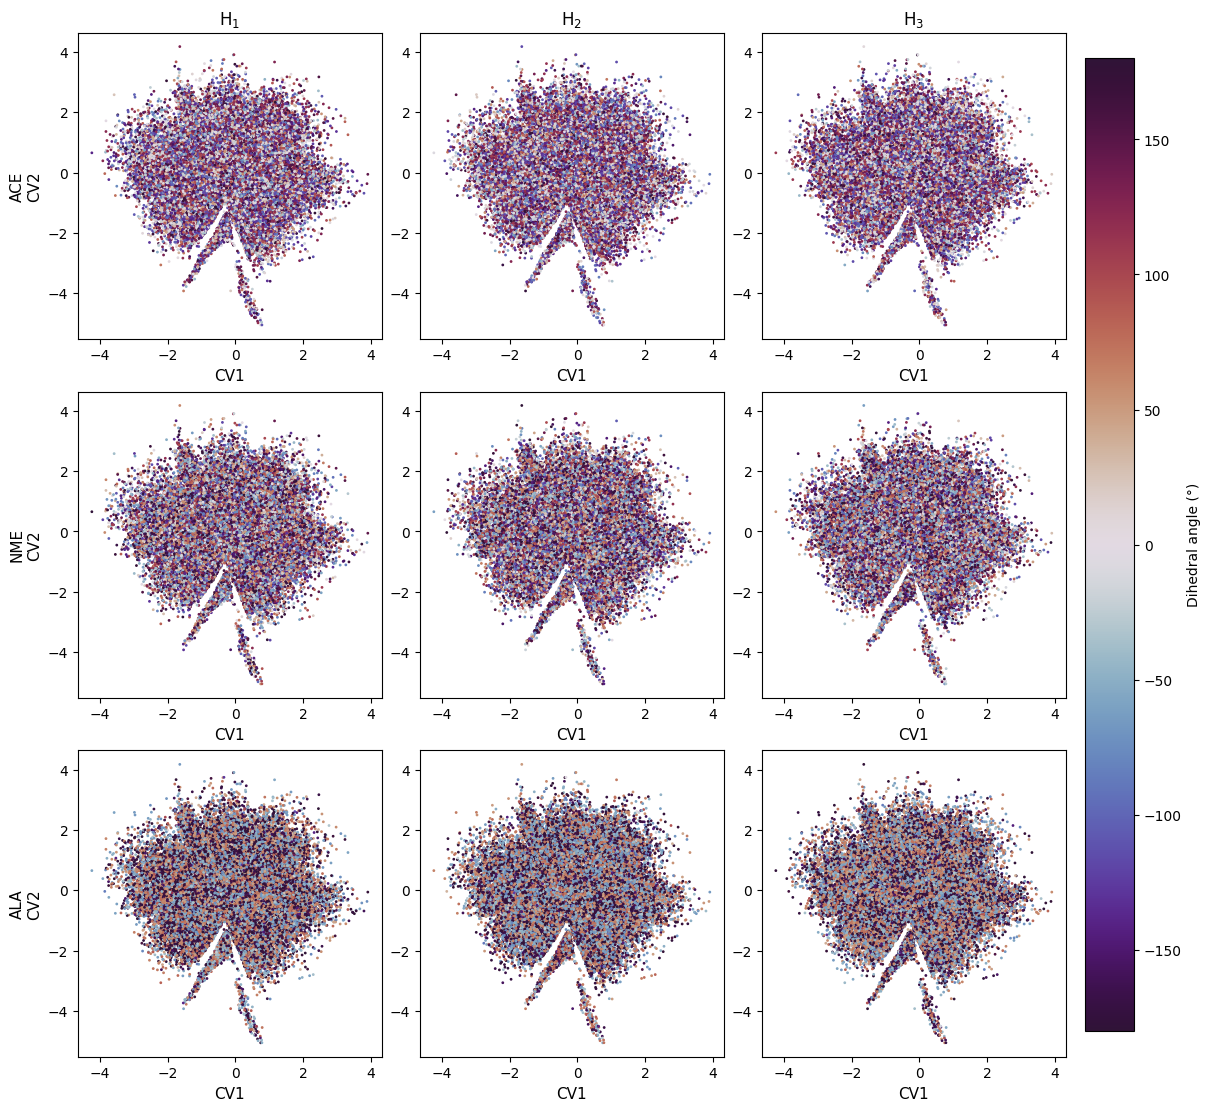

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# --- settings ---
vmin, vmax = -180, 180
cmap = 'twilight_shifted'  # ideal for periodic angles

# Helper to align array lengths (if needed)
def align(proj, arr):
    if arr is None:
        return None, None
    n = min(len(proj), len(arr))
    return proj[:n], arr[:n]

# Align ACE, NME, ALA-SC arrays with proj
proj_ace, ace_plot = align(proj, ace_methyl_deg)
proj_nme, nme_plot = align(proj, nme_methyl_deg)
proj_sc,  sc_plot  = align(proj, ala_sc_methyl_deg)

rows = [("ACE", proj_ace, ace_plot),
        ("NME", proj_nme, nme_plot),
        ("ALA", proj_sc, sc_plot)]

titles = [r"H$_1$", r"H$_2$", r"H$_3$"]

fig, axes = plt.subplots(3, 3, figsize=(12, 11), constrained_layout=True)

for r, (label, pj, data) in enumerate(rows):
    for c in range(3):
        ax = axes[r, c]
        if data is not None and data.shape[1] >= (c + 1):
            sca = ax.scatter(pj[:, 0], pj[:, 1],
                             c=data[:, c], cmap=cmap, s=1,
                             vmin=vmin, vmax=vmax)
        else:
            ax.text(0.5, 0.5, "not found" if data is None else f"no H{c+1}",
                    ha='center', va='center', fontsize=11, alpha=0.8)
        if r == 0:
            ax.set_title(titles[c], fontsize=12)
        if c == 0:
            ax.set_ylabel(label + "\nCV2", fontsize=11)
        ax.set_xlabel("CV1", fontsize=11)

# Shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.95, pad=0.02)
cbar.set_label("Dihedral angle (°)")

# Optional title
# fig.suptitle("Methyl dihedrals: ACE / NME / ALA", fontsize=14, y=1.02)

# --- save figure at 300 dpi ---
plt.savefig("Fig7_methyl_dihedrals.png", dpi=300, bbox_inches='tight')

# Show figure interactively
plt.show()



# phi psi analysis

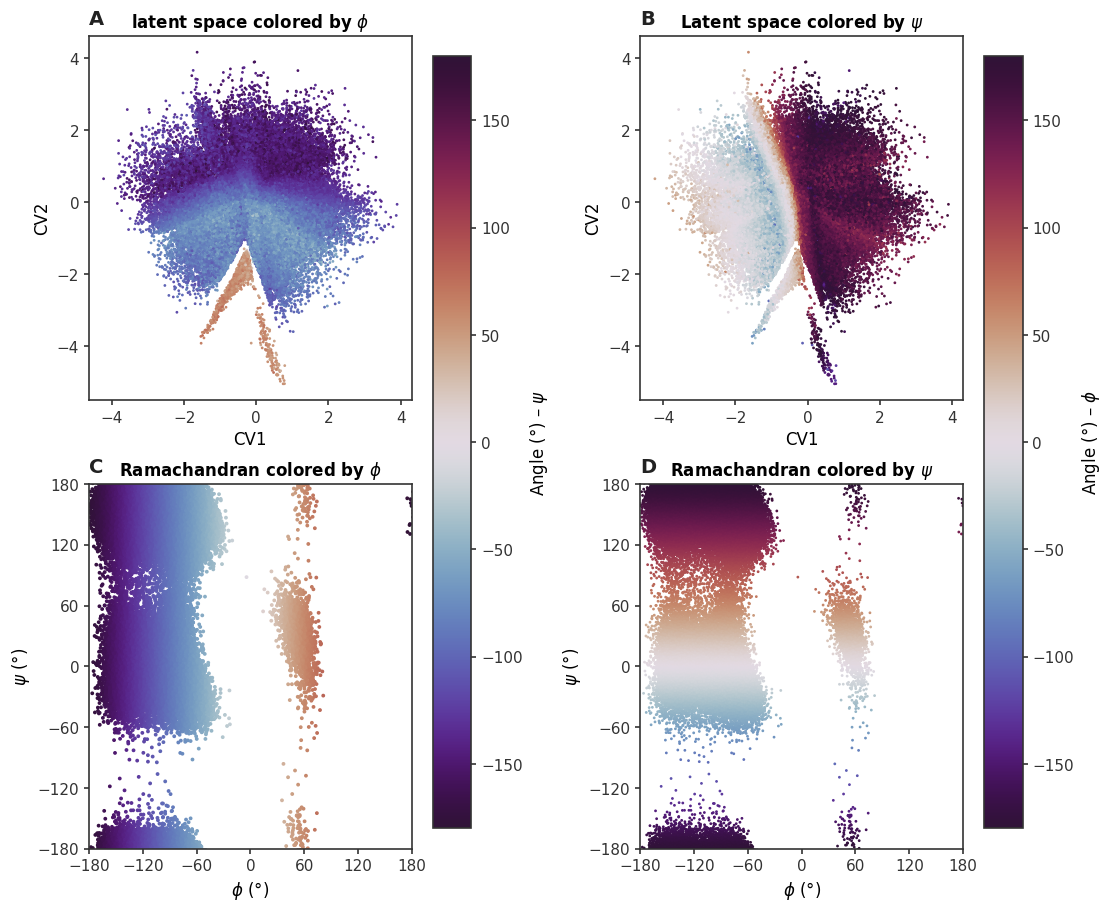

In [13]:
# === Recompute phi/psi and plot with periodic-aware tiling (consistent colors) ===
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------- INPUT ----------
conf = "../../../dataset_aladip/alaninedipeptide_H.pdb"
traj = "../../../dataset_aladip/alaninedipeptide_reduced.xtc"

# 'proj' must be shape (n_frames, 2), with CV1 and CV2
# I assume 'proj' is already defined; otherwise load it first.

# ---------- LOAD TRAJECTORY ----------
t = md.load_xtc(traj, top=conf)
top = t.topology

# ---------- Compute phi/psi (choose a residue with both defined; prefer ALA) ----------
phi_idx, phi_all = md.compute_phi(t)  # radians
psi_idx, psi_all = md.compute_psi(t)  # radians

def _res_from_quad(q):
    return top.atom(q[1]).residue  # the 2nd atom is the CA of the target residue

phi_res = [_res_from_quad(q) for q in phi_idx]
psi_res = [_res_from_quad(q) for q in psi_idx]

candidates = [r for r in set(phi_res).intersection(psi_res) if r.name.upper() == "ALA"]
if not candidates:
    candidates = list(set(phi_res).intersection(psi_res))
center_res = sorted(candidates, key=lambda r: r.index)[0]

def _pick_angle_for_res(idxs, vals, res):
    for i, q in enumerate(idxs):
        if top.atom(q[1]).residue.index == res.index:
            return vals[:, i]
    return None

phi = _pick_angle_for_res(phi_idx, phi_all, center_res)
psi = _pick_angle_for_res(psi_idx, psi_all, center_res)

# ---------- Convert & wrap to [-180, 180) ----------
def wrap_deg(arr_rad):
    deg = np.degrees(arr_rad)
    return ((deg + 180.0) % 360.0) - 180.0

phi_deg = wrap_deg(phi)
psi_deg = wrap_deg(psi)

# ---------- Align lengths with proj ----------
def align_lengths(*arrays):
    n = min(a.shape[0] for a in arrays if a is not None)
    return tuple(a[:n] if a is not None else None for a in arrays)

proj_a, phi_a, psi_a = align_lengths(proj, phi_deg, psi_deg)

# ---------- Periodicity-aware tiling (with consistent colors) ----------
def tile_ramachandran(phi_deg, psi_deg, c=None, thr=150.0):
    """
    Duplicate points near the ±180° borders by translating them by ±360° in φ/ψ.
    Returns phi_tiled, psi_tiled, c_tiled (if c is not None).
    The masks used are also applied to 'c' so lengths match.
    """
    segs_phi = [phi_deg]
    segs_psi = [psi_deg]
    segs_c   = [c] if c is not None else None

    left   = phi_deg < -thr
    right  = phi_deg >  thr
    bottom = psi_deg < -thr
    top    = psi_deg >  thr

    def _append(mask, dphi, dpsi):
        if np.any(mask):
            segs_phi.append(phi_deg[mask] + dphi)
            segs_psi.append(psi_deg[mask] + dpsi)
            if segs_c is not None:
                segs_c.append(c[mask])

    # edges
    _append(left,   +360,    0)
    _append(right,  -360,    0)
    _append(bottom,    0, +360)
    _append(top,       0, -360)
    # corners
    _append(left & bottom,  +360, +360)
    _append(left & top,     +360, -360)
    _append(right & bottom, -360, +360)
    _append(right & top,    -360, -360)

    phi_tiled = np.concatenate(segs_phi)
    psi_tiled = np.concatenate(segs_psi)
    if segs_c is not None:
        c_tiled = np.concatenate(segs_c)
    else:
        c_tiled = None
    return phi_tiled, psi_tiled, c_tiled

# Tile separately for the two colorings (ψ-colored and φ-colored)
phi_tile_psiC, psi_tile_psiC, psi_colors = tile_ramachandran(phi_a, psi_a, c=psi_a, thr=150.0)
phi_tile_phiC, psi_tile_phiC, phi_colors = tile_ramachandran(phi_a, psi_a, c=phi_a, thr=150.0)

# ---------- Cyclic colormap ----------
vmin, vmax = -180, 180
cmap = 'twilight_shifted'
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ---------- Figure 2x2 ----------
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

# (1) CV scatter colored by ψ
ax = axes[0, 1]
s1 = ax.scatter(proj_a[:, 0], proj_a[:, 1], c=psi_a, s=1, cmap=cmap, norm=norm)
ax.set_title(r"Latent space colored by $\psi$", fontsize=12)
ax.set_xlabel("CV1"); ax.set_ylabel("CV2")
add_panel_label(ax, "B")

# (2) CV scatter colored by φ
ax = axes[0, 0]
s2 = ax.scatter(proj_a[:, 0], proj_a[:, 1], c=phi_a, s=1, cmap=cmap, norm=norm)
ax.set_title(r"latent space colored by $\phi$", fontsize=12)
ax.set_xlabel("CV1"); ax.set_ylabel("CV2")
add_panel_label(ax, "A")

# (3) Ramachandran colored by ψ (tiling + consistent colors)
ax = axes[1, 1]
s3 = ax.scatter(phi_tile_psiC, psi_tile_psiC, c=psi_colors, s=1, cmap=cmap, norm=norm)
ax.set_title(r"Ramachandran colored by $\psi$", fontsize=12)
ax.set_xlabel(r"$\phi$ (°)"); ax.set_ylabel(r"$\psi$ (°)")
ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax)
ax.set_xticks([-180,-120,-60,0,60,120,180])
ax.set_yticks([-180,-120,-60,0,60,120,180])
add_panel_label(ax, "D")

# (4) Ramachandran colored by φ (tiling + consistent colors)
ax = axes[1, 0]
s4 = ax.scatter(phi_tile_phiC, psi_tile_phiC, c=phi_colors, s=3, cmap=cmap, norm=norm)
ax.set_title(r"Ramachandran colored by $\phi$", fontsize=12)
ax.set_xlabel(r"$\phi$ (°)"); ax.set_ylabel(r"$\psi$ (°)")
ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax)
ax.set_xticks([-180,-120,-60,0,60,120,180])
ax.set_yticks([-180,-120,-60,0,60,120,180])
add_panel_label(ax, "C")

# Shared colorbars (one per column)
sm_psi = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm_psi.set_array([])
sm_phi = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm_phi.set_array([])

cbar_left  = fig.colorbar(sm_psi, ax=[axes[0,0], axes[1,0]], shrink=0.95, pad=0.02)
cbar_left.set_label(r"Angle (°) – $\psi$")
cbar_right = fig.colorbar(sm_phi, ax=[axes[0,1], axes[1,1]], shrink=0.95, pad=0.02)
cbar_right.set_label(r"Angle (°) – $\phi$")

# Optional title
# fig.suptitle(r"φ/ψ recomputed with periodic-aware plotting (−180° … 180°)", fontsize=14, y=1.02)

# --- save at 300 dpi ---
plt.savefig("Fig7_phi_psi_norm.png", dpi=300, bbox_inches='tight')

plt.show()


# Ramachandran analysis

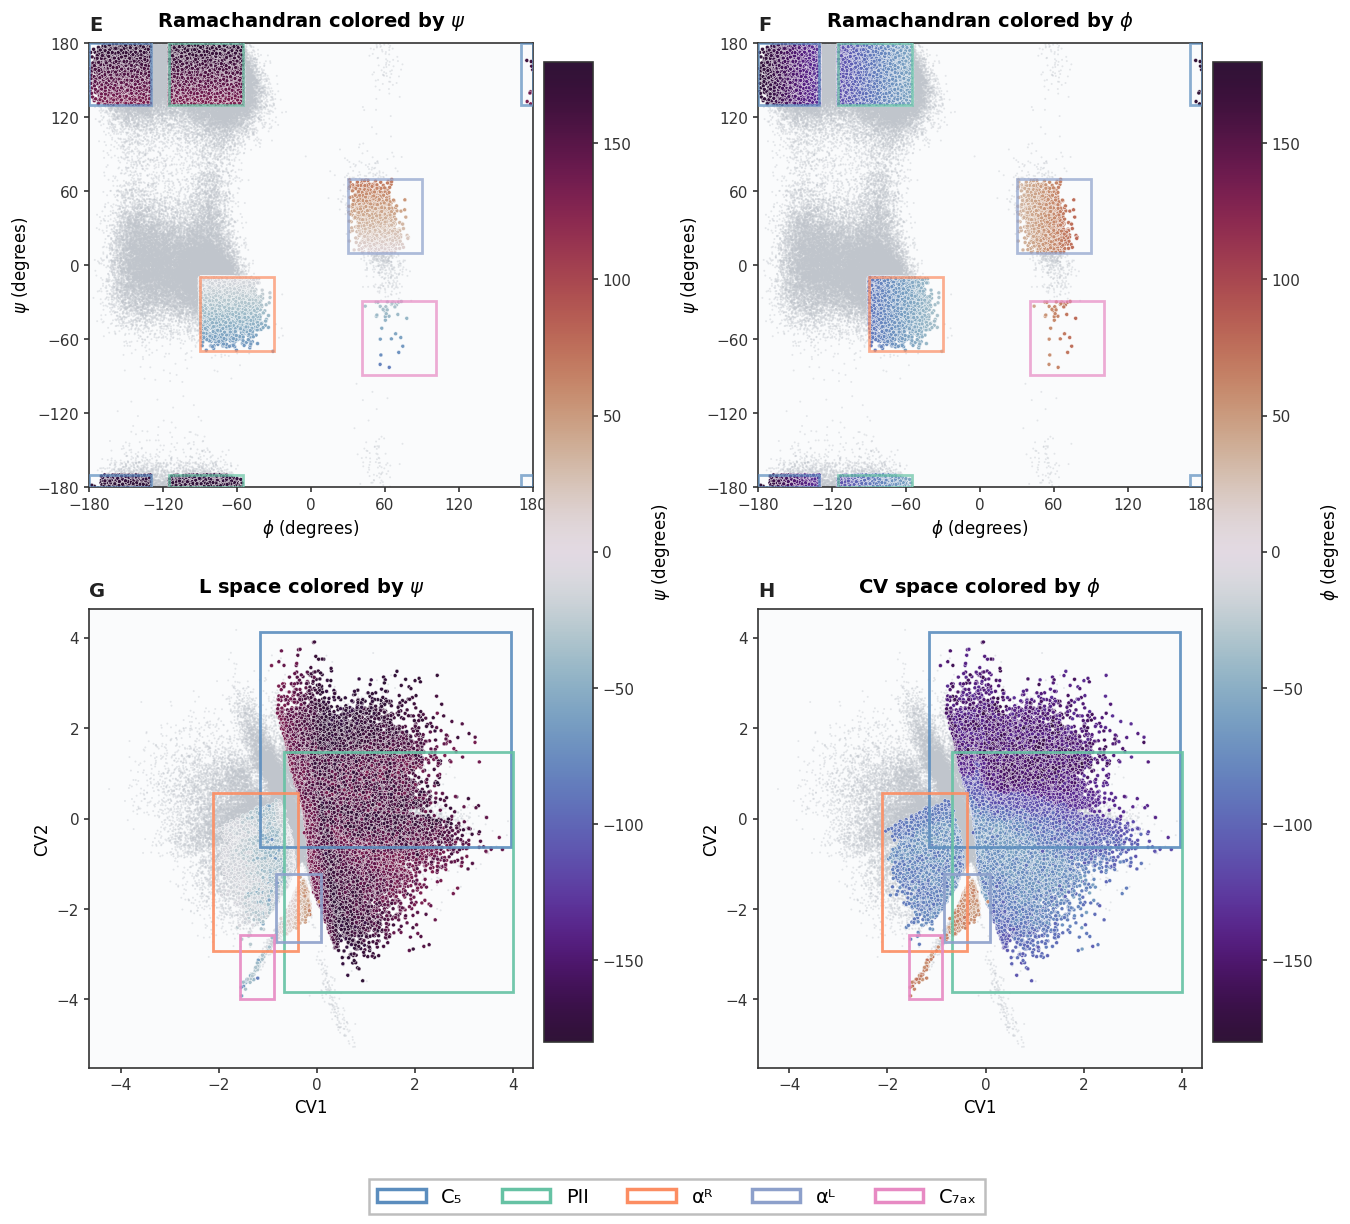

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, Patch

# --------------------------------------------
# INPUT: proj (n,2), phi_deg (n,), psi_deg (n,)
# --------------------------------------------

def angdiff_deg(a, b):
    """Compute the angular difference in degrees within [-180, 180]."""
    return (a - b + 180.0) % 360.0 - 180.0

def in_box_toroidal(phi, psi, phi0, psi0, tol):
    """Check if (phi, psi) lies within a toroidal box centered at (phi0, psi0)."""
    dphi = np.abs(angdiff_deg(phi, phi0))
    dpsi = np.abs(angdiff_deg(psi, psi0))
    return (dphi <= tol) & (dpsi <= tol)

def tile_ramachandran(phi_deg, psi_deg, c=None, thr=150.0):
    """
    Duplicate points near the ±180° edges by shifting them ±360° in φ/ψ.
    """
    segs_phi = [phi_deg]
    segs_psi = [psi_deg]
    segs_c   = [c] if c is not None else None

    left   = phi_deg < -thr
    right  = phi_deg >  thr
    bottom = psi_deg < -thr
    top    = psi_deg >  thr

    def _append(mask, dphi, dpsi):
        if np.any(mask):
            segs_phi.append(phi_deg[mask] + dphi)
            segs_psi.append(psi_deg[mask] + dpsi)
            if segs_c is not None:
                segs_c.append(c[mask])

    # Edges
    _append(left,   +360,    0)
    _append(right,  -360,    0)
    _append(bottom,    0, +360)
    _append(top,       0, -360)
    # Corners
    _append(left & bottom,  +360, +360)
    _append(left & top,     +360, -360)
    _append(right & bottom, -360, +360)
    _append(right & top,    -360, -360)

    phi_tiled = np.concatenate(segs_phi)
    psi_tiled = np.concatenate(segs_psi)
    if segs_c is not None:
        c_tiled = np.concatenate(segs_c)
    else:
        c_tiled = None
    return phi_tiled, psi_tiled, c_tiled

# ---------- REGIONS ----------
tol_deg = 30.0
regions = {
    "C5":     {"center": (-160.0, +160.0), "label": "C₅", "color": "#5B8DBE"},
    "PII":    {"center": ( -85.0, +160.0), "label": "PII", "color": "#66C2A4"},
    "alphaR": {"center": ( -60.0,  -40.0), "label": "αᴿ", "color": "#FC8D62"},
    "alphaL": {"center": ( +60.0,  +40.0), "label": "αᴸ", "color": "#8DA0CB"},
    "C7ax":   {"center": ( +71.0,  -59.0), "label": "C₇ₐₓ", "color": "#E78AC3"},
}
order = ["C5", "PII", "alphaR", "alphaL", "C7ax"]

# ---------- DATA ----------
n = min(len(proj), len(phi_deg), len(psi_deg))
cv  = np.asarray(proj[:n, :2])
phi = np.asarray(phi_deg[:n])
psi = np.asarray(psi_deg[:n])

# ---------- MASKS ----------
masks = {}
used = np.zeros(n, dtype=bool)
for name in order:
    phi0, psi0 = regions[name]["center"]
    m = in_box_toroidal(phi, psi, phi0, psi0, tol_deg) & (~used)
    masks[name] = m
    used |= m

# ---------- TOROIDAL BOX (φ/ψ plane) ----------
def add_toroidal_box(ax, center, tol, color='gray', alpha=0.15, lw=1.5):
    """Draw a toroidal box around (phi0, psi0) handling wrap-around at ±180°."""
    phi0, psi0 = center
    x1, x2 = phi0 - tol, phi0 + tol
    y1, y2 = psi0 - tol, psi0 + tol
    
    def split(a1, a2):
        seg = []
        if a1 < -180:
            seg += [(a1 + 360, 180), (-180, a2)]
        elif a2 > 180:
            seg += [(a1, 180), (-180, a2 - 360)]
        else:
            seg += [(a1, a2)]
        return seg
    
    xr, yr = split(x1, x2), split(y1, y2)
    for xa in xr:
        for ya in yr:
            rect = Rectangle((xa[0], ya[0]), xa[1]-xa[0], ya[1]-ya[0],
                           facecolor='none', edgecolor=color,
                           linewidth=lw, alpha=alpha, zorder=3)
            ax.add_patch(rect)

# ---------- CV BOX ----------
def add_cv_box(ax, pts, color='gray', lw=2.0, alpha=0.7, pad=0.05, zorder=4):
    """
    Draw a rectangular box enclosing points 'pts' (shape: [m,2]) in CV space.
    pad: fraction of the box size added as margin (default 5%).
    """
    if pts.shape[0] == 0:
        return
    x = pts[:, 0]
    y = pts[:, 1]
    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)
    dx = xmax - xmin
    dy = ymax - ymin
    px = dx * pad if dx > 0 else max(1e-6, np.abs(xmin) * pad + 1e-3)
    py = dy * pad if dy > 0 else max(1e-6, np.abs(ymin) * pad + 1e-3)

    rect = Rectangle((xmin - px, ymin - py),
                     (xmax - xmin) + 2*px, (ymax - ymin) + 2*py,
                     facecolor='none', edgecolor=color,
                     linewidth=lw, alpha=alpha, zorder=zorder)
    ax.add_patch(rect)

# ---------- COLOR MAP ----------
vmin, vmax = -180, 180
cmap = 'twilight_shifted'
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ---------- STYLE ----------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#333333",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
})

# ---------- FIGURE LAYOUT ----------
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25, 
                      left=0.08, right=0.94, top=0.94, bottom=0.08)

# ---- (A) Ramachandran colored by ψ ----
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#FAFBFC")

ax1.scatter(phi, psi, s=2, color="#C0C5CC", alpha=0.4, 
           rasterized=True, zorder=2, edgecolors='none')
for name in order:
    idx = masks[name]
    ax1.scatter(phi[idx], psi[idx], c=psi[idx], s=8, 
               cmap=cmap, norm=norm, edgecolor="white", linewidth=0.3,
               rasterized=True, zorder=3)
    add_toroidal_box(ax1, regions[name]["center"], tol_deg, 
                     color=regions[name]["color"], alpha=0.7, lw=2.0)

ax1.set_xlim(-180, 180)
ax1.set_ylim(-180, 180)
ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_yticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_xlabel(r"$\phi$ (degrees)", fontweight="medium")
ax1.set_ylabel(r"$\psi$ (degrees)", fontweight="medium")
ax1.set_title(r"Ramachandran colored by $\psi$", fontsize=14, pad=12)
ax1.set_aspect('equal')
add_panel_label(ax1, "E")

# ---- (B) Ramachandran colored by φ ----
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#FAFBFC")

ax2.scatter(phi, psi, s=2, color="#C0C5CC", alpha=0.4, 
           rasterized=True, zorder=2, edgecolors='none')
for name in order:
    idx = masks[name]
    ax2.scatter(phi[idx], psi[idx], c=phi[idx], s=8, 
               cmap=cmap, norm=norm, edgecolor="white", linewidth=0.3,
               rasterized=True, zorder=3)
    add_toroidal_box(ax2, regions[name]["center"], tol_deg, 
                     color=regions[name]["color"], alpha=0.7, lw=2.0)

ax2.set_xlim(-180, 180)
ax2.set_ylim(-180, 180)
ax2.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax2.set_yticks([-180, -120, -60, 0, 60, 120, 180])
ax2.set_xlabel(r"$\phi$ (degrees)", fontweight="medium")
ax2.set_ylabel(r"$\psi$ (degrees)", fontweight="medium")
ax2.set_title(r"Ramachandran colored by $\phi$", fontsize=14, pad=12)
ax2.set_aspect('equal')
add_panel_label(ax2, "F")

# ---- (C) CV space colored by ψ ----
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor("#FAFBFC")

ax3.scatter(cv[:,0], cv[:,1], s=2, color="#C0C5CC", alpha=0.4,
           rasterized=True, zorder=2, edgecolors='none')
for name in order:
    idx = masks[name]
    ax3.scatter(cv[idx,0], cv[idx,1], c=psi[idx], s=8, 
               cmap=cmap, norm=norm, edgecolor="white", linewidth=0.3,
               rasterized=True, zorder=3)
    add_cv_box(ax3, cv[idx], color=regions[name]["color"], lw=2.0, alpha=0.9)

ax3.set_xlabel("CV1", fontweight="medium")
ax3.set_ylabel("CV2", fontweight="medium")
ax3.set_title(r"L space colored by $\psi$", fontsize=14, pad=12)
add_panel_label(ax3, "G")

# ---- (D) CV space colored by φ ----
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor("#FAFBFC")

ax4.scatter(cv[:,0], cv[:,1], s=2, color="#C0C5CC", alpha=0.4,
           rasterized=True, zorder=2, edgecolors='none')
for name in order:
    idx = masks[name]
    ax4.scatter(cv[idx,0], cv[idx,1], c=phi[idx], s=8, 
               cmap=cmap, norm=norm, edgecolor="white", linewidth=0.3,
               rasterized=True, zorder=3)
    add_cv_box(ax4, cv[idx], color=regions[name]["color"], lw=2.0, alpha=0.9)

ax4.set_xlabel("CV1", fontweight="medium")
ax4.set_ylabel("CV2", fontweight="medium")
ax4.set_title(r"CV space colored by $\phi$", fontsize=14, pad=12)
add_panel_label(ax4, "H")

# ---- COLORBARS ----
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar1 = fig.colorbar(sm, ax=[ax1, ax3], shrink=0.95, pad=0.02)
cbar1.set_label(r"$\psi$ (degrees)", fontweight="medium")

cbar2 = fig.colorbar(sm, ax=[ax2, ax4], shrink=0.95, pad=0.02)
cbar2.set_label(r"$\phi$ (degrees)", fontweight="medium")

# ---- REGION LEGEND ----
legend_handles = []
for name in order:
    patch = Patch(facecolor='white', edgecolor=regions[name]["color"], 
                 linewidth=2.5, label=regions[name]["label"])
    legend_handles.append(patch)

legend = fig.legend(
    legend_handles,
    [regions[name]["label"] for name in order],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),      
    ncol=5,
    frameon=True,
    fancybox=False,
    edgecolor="#BBBBBB",
    framealpha=0.95,
    fontsize=14,                      
    columnspacing=2.0,                
    handlelength=2.5,                 
    handletextpad=0.8               
)
legend.get_frame().set_linewidth(1.8)  

plt.savefig("Fig7_rama_analysis_norm.png", dpi=300, bbox_inches='tight')
plt.show()


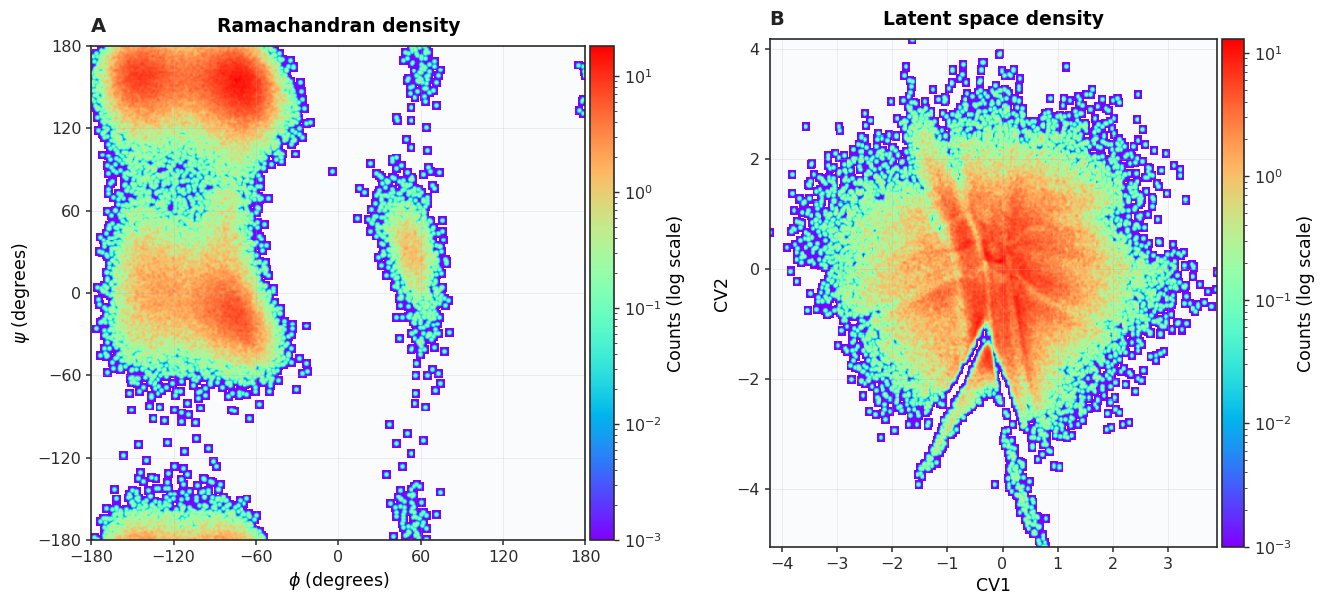

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------------------------------------------------
# INPUT attesi (decommenta la sezione "Esempio" per provare):
#   proj (n,2), phi_deg (n,), psi_deg (n,)
# ------------------------------------------------------------
# # Esempio (rimuovi i # per testare rapidamente):
# np.random.seed(7)
# n = 40000
# phi_deg = (np.random.rand(n) * 360) - 180
# psi_deg = (np.random.rand(n) * 360) - 180
# # Un CV con cluster per rendere visibile la densità
# theta = np.random.rand(n) * 2*np.pi
# r = 2.0 + 0.8*np.random.randn(n)
# proj = np.vstack([r*np.cos(theta), r*np.sin(theta)]).T

# ------------------------------------------------------------
# Utility
# ------------------------------------------------------------
def tile_ramachandran(phi_deg, psi_deg, thr=150.0):
    """Duplica i punti vicini ai bordi ±180° per ridurre artefatti ai bordi."""
    segs_phi = [phi_deg]
    segs_psi = [psi_deg]
    left   = phi_deg < -thr
    right  = phi_deg >  thr
    bottom = psi_deg < -thr
    top    = psi_deg >  thr

    def _append(mask, dphi, dpsi):
        if np.any(mask):
            segs_phi.append(phi_deg[mask] + dphi)
            segs_psi.append(psi_deg[mask] + dpsi)

    # Bordi
    _append(left,   +360,    0)
    _append(right,  -360,    0)
    _append(bottom,    0, +360)
    _append(top,       0, -360)
    # Angoli
    _append(left & bottom,  +360, +360)
    _append(left & top,     +360, -360)
    _append(right & bottom, -360, +360)
    _append(right & top,    -360, -360)

    return np.concatenate(segs_phi), np.concatenate(segs_psi)

def density2d_hist(x, y, bins=180, rng=None, smooth_sigma=1.0):
    """Istogramma 2D con smoothing gaussiano opzionale (se scipy è disponibile)."""
    H, xedges, yedges = np.histogram2d(x, y, bins=bins, range=rng)
    try:
        from scipy.ndimage import gaussian_filter
        if smooth_sigma and smooth_sigma > 0:
            H = gaussian_filter(H, sigma=smooth_sigma)
    except Exception:
        pass
    return H.T, xedges, yedges  # Trasposto per orientamento “imshow-like”

def plot_density_with_cbar(ax, x, y, *,
                           bins=500, rng=None, cmap="rainbow",
                           cbar_label="Counts (log scale)",
                           cbar_size="4.5%", cbar_pad=0.04,
                           smooth_sigma=1.0):
    """
    Crea la mappa di densità su 'ax' e aggiunge una colorbar verticale
    con la stessa altezza del pannello (grazie a make_axes_locatable).
    Ritorna (mesh, cbar).
    """
    H, xedges, yedges = density2d_hist(x, y, bins=bins, rng=rng, smooth_sigma=smooth_sigma)

    # Evita problemi col LogNorm (no zeri)
    finite_vals = H[np.nonzero(H)]
    vmin = max(np.min(finite_vals), 1e-3) if finite_vals.size > 0 else 1e-3
    vmax = np.max(H) if H.size > 0 else 1.0
    norm = LogNorm(vmin=vmin, vmax=vmax)

    X, Y = np.meshgrid(xedges, yedges)
    mesh = ax.pcolormesh(X, Y, H, shading="auto", cmap=cmap, norm=norm, rasterized=True)

    # Colorbar con stessa altezza del pannello
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=cbar_size, pad=cbar_pad)
    cbar = plt.colorbar(mesh, cax=cax)
    cbar.set_label(cbar_label, fontweight="medium")
    cbar.ax.tick_params(length=3.5, width=1)

    return mesh, cbar


# ------------------------------------------------------------
# Stile “professionale”
# ------------------------------------------------------------
mpl.rcParams.update({
    # Tipografia
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11.5,
    # Assi
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelsize": 12.5,
    "axes.titlesize": 13.5,
    "axes.titleweight": "semibold",
    # Ticks
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.color": "#2B2B2B",
    "ytick.color": "#2B2B2B",
    # Griglia
    "grid.linewidth": 0.6,
    "grid.alpha": 0.25,
})

# ------------------------------------------------------------
# Dati (sincronizzazione lunghezze)
# ------------------------------------------------------------
n = min(len(proj), len(phi_deg), len(psi_deg))
cv  = np.asarray(proj[:n, :2])
phi = np.asarray(phi_deg[:n])
psi = np.asarray(psi_deg[:n])

# ------------------------------------------------------------
# Figura: due pannelli di identica dimensione + colorbar ad altezza piena
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))
ax1, ax2 = axes

# Sfondo chiaro
for ax in axes:
    ax.set_facecolor("#FAFBFC")

# ---- (A) Ramachandran density (φ, ψ) ----
phi_t, psi_t = tile_ramachandran(phi, psi, thr=150.0)
mesh1, cbar1 = plot_density_with_cbar(
    ax1, phi_t, psi_t,
    bins=500, rng=[[-180, 180], [-180, 180]],
    cmap="rainbow", cbar_label="Counts (log scale)", smooth_sigma=1.0,
    cbar_size="4.8%", cbar_pad=0.05
)
ax1.set_xlim(-180, 180)
ax1.set_ylim(-180, 180)
ax1.set_aspect("equal")
ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_yticks([-180, -120, -60, 0, 60, 120, 180])
ax1.grid(True, which="major")
ax1.set_xlabel(r"$\phi$ (degrees)", fontweight="medium")
ax1.set_ylabel(r"$\psi$ (degrees)", fontweight="medium")
ax1.set_title("Ramachandran density", pad=10)
add_panel_label(ax1, "A")

# ---- (B) CV1–CV2 density ----
mesh2, cbar2 = plot_density_with_cbar(
    ax2, cv[:, 0], cv[:, 1],
    bins=500, rng=None,
    cmap="rainbow", cbar_label="Counts (log scale)", smooth_sigma=1.0,
    cbar_size="4.8%", cbar_pad=0.05
)
# Per avere pannelli visivamente simmetrici, forziamo aspect = equal.
ax2.set_aspect("equal")
ax2.grid(True, which="major")
ax2.set_xlabel("CV1", fontweight="medium")
ax2.set_ylabel("CV2", fontweight="medium")
ax2.set_title("Latent space density", pad=10)
add_panel_label(ax2, "B")

# Spaziature globali (niente sovrapposizioni; i cbar hanno altezza dei pannelli)
fig.tight_layout(pad=1.1)

plt.show()


